C:\Users\cashgen\AppData\Local\Temp\ipykernel_17136\4002336808.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=volume_pct.index, y=volume_pct.values, ax=axes[0], palette='Blues')
C:\Users\cashgen\AppData\Local\Temp\ipykernel_17136\4002336808.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=salary_median.index, y=salary_median.values, ax=axes[1], palette='Greens')


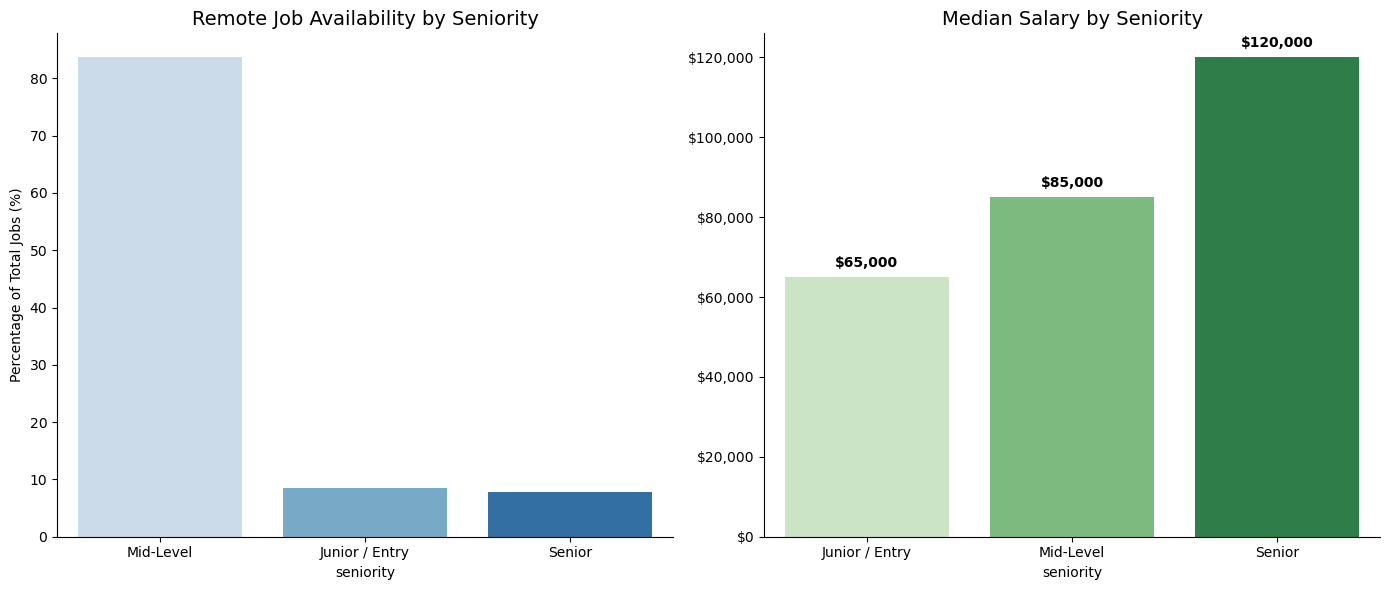

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import StrMethodFormatter

# Load and Clean Data
df = pd.read_csv("data_jobs.csv")
df_remote = df[(df['job_title_short'] == 'Data Analyst') & (df['job_work_from_home'] == True)].copy()
# Categorize Seniority using a custom function
def assign_seniority(title):
    title = str(title).lower()
    if any(word in title for word in ['senior', 'sr', 'lead', 'principal', 'manager']):
        return 'Senior'
    elif any(word in title for word in ['junior', 'jr', 'entry', 'intern']):
        return 'Junior / Entry'
    else:
        return 'Mid-Level'

df_remote['seniority'] = df_remote['job_title'].apply(assign_seniority)

# Calculate Volume and Median Salary
volume_pct = df_remote['seniority'].value_counts(normalize=True) * 100
df_salary = df_remote.dropna(subset=['salary_year_avg'])
salary_median = df_salary.groupby('seniority')['salary_year_avg'].median().reindex(['Junior / Entry', 'Mid-Level', 'Senior'])

# Plot Charts
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(x=volume_pct.index, y=volume_pct.values, ax=axes[0], palette='Blues')
axes[0].set_title('Remote Job Availability by Seniority', fontsize=14)
axes[0].set_ylabel('Percentage of Total Jobs (%)')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
sns.barplot(x=salary_median.index, y=salary_median.values, ax=axes[1], palette='Greens')
axes[1].set_title('Median Salary by Seniority', fontsize=14)
axes[1].yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
axes[1].set_ylabel('')
for i, p in enumerate(axes[1].patches):
    axes[1].annotate(f'${int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontweight='bold')

axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()